In [1]:
# exp05 — GoogLeNet/InceptionV1 · Tiny ImageNet
# Acumula exp_001 (filtros 5a/5b reduzidos) + exp_002 (dropout 0.55)
# + exp_004 (label_smoothing 0.05 só main, aux_weight 0.4, LR warmup)
# Hipótese: substituir MaxPool da Stem por stride convolucional em stem_c2
# (Conv 3x3 stride=2 com he_normal) reduz resolução para 32x32 de forma
# aprendível, diminuindo custo computacional da stem_c3 (192ch × 64×64 → 32×32)
# e melhorando o fluxo de gradiente sem Batch Normalization.
# Meta: fechar o gap main/auxiliar (≥7pp no exp_002) e superar Top-1 > 47%.

import datetime

EXPERIMENTO = {
    "id": "exp_005",
    "hipotese": (
        "Stem com stride convolucional (stem_c2 stride=2, he_normal) em vez de MaxPool "
        "reduz custo 4× na stem_c3, melhora fluxo de gradiente sem BN e fecha gap main/aux."
    ),
    "mudancas": [
        "[exp_001] inception_5a: (256,160,320,32,128,128) → (192,128,256,32,96,96)",
        "[exp_001] inception_5b: (384,192,384,48,128,128) → (256,160,320,32,96,96)",
        "[exp_002] main_dropout: 0.4 → 0.55",
        "[exp_004] label_smoothing: 0.05 só na main_output",
        "[exp_004] loss_weight auxiliar: 0.3 → 0.4",
        "[exp_004] ReduceLROnPlateau patience: 5 → 8",
        "[exp_004] EarlyStopping patience: 15 → 20",
        "[exp_004] LR warmup: 5 épocas (0.001 → 0.01)",
        "[exp_004] augmentation: nível exp_002 (sem RandomBrightness, rotação 0.1)",
        "[exp_005] Stem: stem_c2 stride=2 (he_normal) + remoção do stem_pool",
        "[exp_005] stem_c1/stem_c3 mantêm glorot_uniform",
    ],
    "resultado_top1": None,
    "resultado_top5": None,
    "epocas": None,
}

print(f"[{datetime.datetime.now():%Y-%m-%d %H:%M}] {EXPERIMENTO['id']}")
print(f"Hipótese: {EXPERIMENTO['hipotese']}")
print("\nMudanças acumuladas:")
for m in EXPERIMENTO["mudancas"]:
    print(f"  • {m}")

[2026-05-05 11:58] exp_005
Hipótese: Stem com stride convolucional (stem_c2 stride=2, he_normal) em vez de MaxPool reduz custo 4× na stem_c3, melhora fluxo de gradiente sem BN e fecha gap main/aux.

Mudanças acumuladas:
  • [exp_001] inception_5a: (256,160,320,32,128,128) → (192,128,256,32,96,96)
  • [exp_001] inception_5b: (384,192,384,48,128,128) → (256,160,320,32,96,96)
  • [exp_002] main_dropout: 0.4 → 0.55
  • [exp_004] label_smoothing: 0.05 só na main_output
  • [exp_004] loss_weight auxiliar: 0.3 → 0.4
  • [exp_004] ReduceLROnPlateau patience: 5 → 8
  • [exp_004] EarlyStopping patience: 15 → 20
  • [exp_004] LR warmup: 5 épocas (0.001 → 0.01)
  • [exp_004] augmentation: nível exp_002 (sem RandomBrightness, rotação 0.1)
  • [exp_005] Stem: stem_c2 stride=2 (he_normal) + remoção do stem_pool
  • [exp_005] stem_c1/stem_c3 mantêm glorot_uniform


## Histórico de Experimentos

| ID | Mudanças-chave | Top-1 val (main) | Top-1 val (aux) | Top-5 val | Δ Top-1 |
|---|---|---|---|---|---|
| baseline | Modelo original | 39.88% | — | — | — |
| exp_001 | inception_5a/5b: canais reduzidos ~30% | 40.08% | 44.76% | 71.05% | +0.20pp |
| exp_002 | main_dropout: 0.4 → 0.55 | 39.29%* | 46.58% | 71.79% | +1.08pp (aux) |
| exp_003 | label_smoothing 0.1 (ambas) + ReduceLR patience=5 + aug+ | 0.50% ❌ | 2.50% ❌ | 2.50% ❌ | colapso (16 épocas) |
| exp_004 | label_smoothing 0.05 (só main) + peso aux 0.4 + warmup | *41.88%* | *47.52%* | *71.91%* | — |
| **exp_005** | **Stem: stride convolucional (stem_c2 stride=2, he_normal) + sem stem_pool** | *(pendente)* | *(pendente)* | *(pendente)* |  |

> \*O Top-1 do exp_002 reportado pelo `evaluate()` usa a saída principal (39.29%).
> A saída auxiliar atingiu 46.58% — gap de ~7pp que exp_004/005 visam eliminar.

> **Racional exp_005 — Stem com stride convolucional:**
> No exp_004, a `stem_c3` opera com 192 filtros sobre mapas 64×64 (custo elevado).
> Mover o downsampling para `stem_c2` via `stride=2` (em vez de MaxPool após `stem_c3`)
> reduz 4× o custo da `stem_c3` e preserva mais informação aprendível durante a
> descida de resolução — especialmente relevante sem Batch Normalization.
> O inicializador `he_normal` na `stem_c2` compensa a ausência de BN nessa camada
> com stride, onde os gradientes iniciais tendem a ser menores.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools, math, csv, os, shutil, zipfile, warnings, datetime
import requests
from PIL import Image
from io import BytesIO
from pathlib import Path
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

2026-05-05 11:58:43.092167: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777982323.281842      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777982323.336937      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777982323.763539      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777982323.763588      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777982323.763591      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Hiperparâmetros ──────────────────────────────────────────────────────────
EPOCHS         = 100
BATCH_SIZE     = 128
NUM_CLASSES    = 200
IMG_SIZE       = 64
INITIAL_LR     = 0.01
WARMUP_EPOCHS  = 5       # mantido do exp_004
WARMUP_LR      = 0.001   # mantido do exp_004
DROPOUT_MAIN   = 0.55    # exp_002
LABEL_SMOOTH   = 0.05    # exp_004 — só na main_output
AUX_WEIGHT     = 0.4     # exp_004

tf.random.set_seed(42)
np.random.seed(42)
print(f"{EPOCHS} épocas | batch {BATCH_SIZE} | {IMG_SIZE}×{IMG_SIZE} | {NUM_CLASSES} classes")
print(f"dropout={DROPOUT_MAIN} | label_smoothing={LABEL_SMOOTH} (só main) | aux_weight={AUX_WEIGHT}")
print(f"LR warmup: {WARMUP_EPOCHS} épocas ({WARMUP_LR} → {INITIAL_LR})")
print(f"[exp_005] Stem: Conv3x3(64,s1,glorot) → Conv3x3(64,s2,he_normal) → Conv3x3(192,s1,glorot) — sem stem_pool")

100 épocas | batch 128 | 64×64 | 200 classes
dropout=0.55 | label_smoothing=0.05 (só main) | aux_weight=0.4
LR warmup: 5 épocas (0.001 → 0.01)
[exp_005] Stem: Conv3x3(64,s1,glorot) → Conv3x3(64,s2,he_normal) → Conv3x3(192,s1,glorot) — sem stem_pool


In [4]:
TINY_URL = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
DATA_DIR = Path('/kaggle/working/tiny-imagenet-200')
ZIP_PATH = Path('/kaggle/working/tiny-imagenet-200.zip')

if not ZIP_PATH.exists():
    print('Baixando Tiny ImageNet (~236 MB)...')
    r = requests.get(TINY_URL, stream=True)
    total = int(r.headers.get('content-length', 0))
    downloaded = 0
    with open(ZIP_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            f.write(chunk)
            downloaded += len(chunk)
            print(f'\r  {downloaded/1e6:.1f}/{total/1e6:.1f} MB', end='')
    print('\nDownload completo!')
else:
    print('ZIP já existe.')

if not DATA_DIR.exists():
    print('Extraindo...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/kaggle/working')
    print('Extração concluída.')
else:
    print('Dataset já extraído.')

# Reorganiza val/ → val_organized/class_id/img.JPEG
val_organized = DATA_DIR / 'val_organized'
if not val_organized.exists():
    print('Reorganizando val/...')
    val_organized.mkdir(parents=True)
    with open(DATA_DIR / 'val' / 'val_annotations.txt') as f:
        for line in f:
            fname, class_id = line.strip().split('\t')[:2]
            d = val_organized / class_id
            d.mkdir(exist_ok=True)
            shutil.copy(DATA_DIR / 'val' / 'images' / fname, d / fname)
    print(f'Val reorganizado: {len(list(val_organized.iterdir()))} classes')
else:
    print('val_organized já existe.')

TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = val_organized
print(f'Treino: {TRAIN_DIR} | Val: {VAL_DIR}')

Baixando Tiny ImageNet (~236 MB)...
  248.1/248.1 MB
Download completo!
Extraindo...
Extração concluída.
Reorganizando val/...
Val reorganizado: 200 classes
Treino: /kaggle/working/tiny-imagenet-200/train | Val: /kaggle/working/tiny-imagenet-200/val_organized


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, label_mode='categorical', shuffle=True, seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False
)
CLASS_NAMES = train_ds.class_names
print(f'Classes: {len(CLASS_NAMES)}')

def normalize(img, lbl):
    return tf.cast(img, tf.float32) / 255.0, lbl

# Augmentation — mantido no nível do exp_002/004
# (sem RandomBrightness, rotação=0.1)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='augmentation')

train_ds = (
    train_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (augment(img, training=True), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    val_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
print('Pipelines prontos.')

Found 100000 files belonging to 200 classes.


I0000 00:00:1777982374.377137      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 10000 files belonging to 200 classes.
Classes: 200
Pipelines prontos.


In [6]:
def inception_module(x, f1, f3r, f3, f5r, f5, fp, name):
    """Módulo Inception: 4 ramos paralelos (Szegedy et al., 2014)."""
    ki = 'glorot_uniform'
    bi = tf.keras.initializers.Constant(0.2)
    kw = dict(padding='same', activation='relu', kernel_initializer=ki, bias_initializer=bi)

    b1 = tf.keras.layers.Conv2D(f1,  (1,1), **kw, name=f'{name}_1x1')(x)

    b2 = tf.keras.layers.Conv2D(f3r, (1,1), **kw, name=f'{name}_3x3_reduce')(x)
    b2 = tf.keras.layers.Conv2D(f3,  (3,3), **kw, name=f'{name}_3x3')(b2)

    b3 = tf.keras.layers.Conv2D(f5r, (1,1), **kw, name=f'{name}_5x5_reduce')(x)
    b3 = tf.keras.layers.Conv2D(f5,  (5,5), **kw, name=f'{name}_5x5')(b3)

    b4 = tf.keras.layers.MaxPooling2D((3,3), strides=(1,1), padding='same', name=f'{name}_pool')(x)
    b4 = tf.keras.layers.Conv2D(fp,  (1,1), **kw, name=f'{name}_pool_proj')(b4)

    return tf.keras.layers.Concatenate(axis=-1, name=name)([b1, b2, b3, b4])

In [7]:
def build_googlenet(num_classes=200, img_size=64, dropout=0.55):
    """
    GoogLeNet adaptado para 64×64. Acumula mudanças de exp_001, exp_002 e exp_004.

    [exp_005] Stem redesenhada:
      ANTES (exp_004):
        Conv3x3(64, s1, glorot) → 64×64
        Conv3x3(64, s1, glorot) → 64×64
        Conv3x3(192, s1, glorot) → 64×64  ← caro: 192ch × 4096 posições
        MaxPool(s2) → 32×32

      DEPOIS (exp_005):
        Conv3x3(64, s1, glorot_uniform) → 64×64
        Conv3x3(64, s2, he_normal)      → 32×32  ← downsampling aprendível
        Conv3x3(192, s1, glorot_uniform) → 32×32  ← 4× mais barato
        [stem_pool REMOVIDO]

    Justificativa he_normal em stem_c2:
      - stride=2 reduz o mapa; sem BN, os gradientes iniciais são menores
      - he_normal compensa isso para camadas com ReLU, onde glorot tende
        a subestimar a variância necessária para um aprendizado inicial rápido.
    """
    bi      = tf.keras.initializers.Constant(0.2)
    kw_g    = dict(padding='same', activation='relu',
                   kernel_initializer='glorot_uniform', bias_initializer=bi)
    kw_he   = dict(padding='same', activation='relu',
                   kernel_initializer='he_normal', bias_initializer=bi)

    inp = tf.keras.layers.Input(shape=(img_size, img_size, 3), name='input')

    # ── Stem exp_005 ─────────────────────────────────────────────────────────
    # [INPUT]: (64 × 64 × 3)
    x = tf.keras.layers.Conv2D(64,  (3,3), **kw_g,  name='stem_c1')(inp)       # → 64×64×64
    x = tf.keras.layers.Conv2D(64,  (3,3), strides=2, **kw_he, name='stem_c2')(x) # → 32×32×64
    x = tf.keras.layers.Conv2D(192, (3,3), **kw_g,  name='stem_c3')(x)         # → 32×32×192
    # stem_pool REMOVIDO — downsampling já realizado por stem_c2 (stride=2)
    # [SAÍDA STEM]: (32 × 32 × 192) → entra no inception_3a

    # ── Bloco 3 ──────────────────────────────────────────────────────────────
    x = inception_module(x,  64,  96, 128, 16,  32,  32, 'inception_3a')
    x = inception_module(x, 128, 128, 192, 32,  96,  64, 'inception_3b')
    x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same', name='pool_3')(x)

    # ── Bloco 4 ──────────────────────────────────────────────────────────────
    x = inception_module(x, 192,  96, 208, 16,  48,  64, 'inception_4a')

    # ── Classificador Auxiliar ───────────────────────────────────────────────
    aux = tf.keras.layers.AveragePooling2D((5,5), strides=3, padding='same', name='aux_pool')(x)
    aux = tf.keras.layers.Conv2D(128, (1,1), **kw_g, name='aux_conv')(aux)
    aux = tf.keras.layers.Flatten(name='aux_flat')(aux)
    aux = tf.keras.layers.Dense(1024, activation='relu', name='aux_dense')(aux)
    aux = tf.keras.layers.Dropout(0.3, name='aux_drop')(aux)
    aux_out = tf.keras.layers.Dense(num_classes, activation='softmax', name='auxiliary_output')(aux)

    x = inception_module(x, 160, 112, 224, 24,  64,  64, 'inception_4b')
    x = inception_module(x, 128, 128, 256, 24,  64,  64, 'inception_4c')
    x = inception_module(x, 112, 144, 288, 32,  64,  64, 'inception_4d')
    x = inception_module(x, 256, 160, 320, 32, 128, 128, 'inception_4e')
    x = tf.keras.layers.MaxPooling2D((3,3), strides=2, padding='same', name='pool_4')(x)

    # ── Bloco 5 — canais reduzidos (exp_001) ─────────────────────────────────
    x = inception_module(x, 192, 128, 256, 32,  96,  96, 'inception_5a')  # 640ch
    x = inception_module(x, 256, 160, 320, 32,  96,  96, 'inception_5b')  # 768ch

    # ── Cabeça principal — dropout 0.55 (exp_002) ────────────────────────────
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x = tf.keras.layers.Dropout(dropout, name='main_dropout')(x)
    main_out = tf.keras.layers.Dense(num_classes, activation='softmax', name='main_output')(x)

    return tf.keras.Model(inputs=inp, outputs=[main_out, aux_out], name='GoogLeNet_exp005')


model = build_googlenet(NUM_CLASSES, IMG_SIZE, DROPOUT_MAIN)
model.summary()

# Verificação de shapes na Stem
print("\n── Verificação Stem exp_005 ──")
for name in ['stem_c1', 'stem_c2', 'stem_c3']:
    layer = model.get_layer(name)
    print(f"  {name}: output={layer.output.shape} | "
          f"kernel_initializer={layer.kernel_initializer.__class__.__name__} | "
          f"strides={layer.strides}")

Model: "GoogLeNet_exp005"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_c1 (Conv2D)    │ (None, 64, 64,    │      1,792 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_c2 (Conv2D)    │ (None, 32, 32,    │     36,928 │ stem_c1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_c3 (Conv2D)    │ (None, 32, 32,    │    110,784 │ stem_c2[0][0]     │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3_r… │ (None, 32, 32,    │     18,528 │ stem_c3[0][0]     │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5_r… │ (None, 32, 32,    │      3,088 │ stem_c3[0][0]     │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_pool   │ (None, 32, 32,    │          0 │ stem_c3[0][0]     │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_1x1    │ (None, 32, 32,    │     12,352 │ stem_c3[0][0]     │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3    │ (None, 32, 32,    │    110,720 │ inception_3a_3x3… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5    │ (None, 32, 32,    │     12,832 │ inception_3a_5x5… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_pool_… │ (None, 32, 32,    │      6,176 │ inception_3a_poo… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 32, 32,    │          0 │ inception_3a_1x1… │
│ (Concatenate)       │ 256)              │            │ inception_3a_3x3… │
│                     │                   │            │ inception_3a_5x5… │
│                     │                   │            │ inception_3a_poo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_3x3_r… │ (None, 32, 32,    │     32,896 │ inception_3a[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_5x5_r… │ (None, 32, 32,    │      8,224 │ inception_3a[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_pool   │ (None, 32, 32,    │          0 │ inception_3a[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_1x1    │ (None, 32, 32,    │     32,896 │ inception_3a[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,287,152 (39.24 MB)

 Trainable params: 10,287,152 (39.24 MB)

 Non-trainable params: 0 (0.00 B)


── Verificação Stem exp_005 ──
  stem_c1: output=(None, 64, 64, 64) | kernel_initializer=GlorotUniform | strides=(1, 1)
  stem_c2: output=(None, 32, 32, 64) | kernel_initializer=HeNormal | strides=(2, 2)
  stem_c3: output=(None, 32, 32, 192) | kernel_initializer=GlorotUniform | strides=(1, 1)


In [8]:
# exp_005: mesma configuração de loss do exp_004
# label_smoothing=0.05 APENAS na main_output; auxiliar sem smoothing
# loss_weight auxiliar = 0.4 (exp_004)
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=WARMUP_LR, momentum=0.9, nesterov=True),
    loss={
        'main_output':      tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
        'auxiliary_output': tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    },
    loss_weights={'main_output': 1.0, 'auxiliary_output': AUX_WEIGHT},
    metrics={'main_output': ['accuracy'], 'auxiliary_output': ['accuracy']},
)
print('Compilado com sucesso.')
print(f'  LR inicial (warmup): {WARMUP_LR} | LR alvo: {INITIAL_LR}')
print(f'  label_smoothing main={LABEL_SMOOTH} | auxiliary=0.0')
print(f'  loss_weights: main=1.0 | auxiliary={AUX_WEIGHT}')

Compilado com sucesso.
  LR inicial (warmup): 0.001 | LR alvo: 0.01
  label_smoothing main=0.05 | auxiliary=0.0
  loss_weights: main=1.0 | auxiliary=0.4


In [9]:
# Callbacks — mantidos do exp_004 (warmup 5 épocas, ReduceLR patience=8, ES patience=20)

class LRWarmupCallback(tf.keras.callbacks.Callback):
    """Sobe o LR linearmente de warmup_lr até target_lr ao longo de warmup_epochs."""
    def __init__(self, warmup_epochs, warmup_lr, target_lr):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.warmup_lr     = warmup_lr
        self.target_lr     = target_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.warmup_lr + (self.target_lr - self.warmup_lr) * (epoch / self.warmup_epochs)
            self.model.optimizer.learning_rate.assign(lr)
            print(f'  [warmup] época {epoch+1}/{self.warmup_epochs} — LR = {lr:.5f}')
        elif epoch == self.warmup_epochs:
            self.model.optimizer.learning_rate.assign(self.target_lr)
            print(f'  [warmup] concluído — LR fixado em {self.target_lr}')

callbacks = [
    LRWarmupCallback(
        warmup_epochs=WARMUP_EPOCHS,
        warmup_lr=WARMUP_LR,
        target_lr=INITIAL_LR,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_main_output_accuracy', factor=0.5,
        patience=8, min_lr=1e-5, verbose=1, mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_main_output_accuracy', patience=20,
        restore_best_weights=True, verbose=1, mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'googlenet_exp005_best.keras', monitor='val_main_output_accuracy',
        save_best_only=True, verbose=1, mode='max'
    ),
    tf.keras.callbacks.CSVLogger('training_log_exp005.csv'),
]

In [10]:
# Duplica labels para as 2 saídas do modelo
def dual_labels(img, lbl):
    return img, (lbl, lbl)

train_ds_dual = train_ds.map(dual_labels)
val_ds_dual   = val_ds.map(dual_labels)

print(f'Iniciando exp_005 — {EPOCHS} épocas máx.')
history = model.fit(
    train_ds_dual,
    validation_data=val_ds_dual,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Iniciando exp_005 — 100 épocas máx.
  [warmup] época 1/5 — LR = 0.00100
Epoch 1/100


I0000 00:00:1777982386.566531      74 service.cc:152] XLA service 0x7e3bb400dcc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777982386.567429      74 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777982388.386667      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777982418.966917      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - auxiliary_output_accuracy: 0.0052 - auxiliary_output_loss: 5.3259 - loss: 7.4895 - main_output_accuracy: 0.0047 - main_output_loss: 5.3591
Epoch 1: val_main_output_accuracy improved from -inf to 0.00500, saving model to googlenet_exp005_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 257s 277ms/step - auxiliary_output_accuracy: 0.0052 - auxiliary_output_loss: 5.3259 - loss: 7.4895 - main_output_accuracy: 0.0047 - main_output_loss: 5.3591 - val_auxiliary_output_accuracy: 0.0073 - val_auxiliary_output_loss: 5.2926 - val_loss: 7.4159 - val_main_output_accuracy: 0.0050 - val_main_output_loss: 5.2985 - learning_rate: 0.0010
  [warmup] época 2/5 — LR = 0.00280
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - auxiliary_output_accuracy: 0.0088 - auxiliary_output_loss: 5.2719 - loss: 7.4093 - main_output_accuracy: 0.0048 - main_output_loss: 5.3006
Epoch 2: val_main_output_accuracy improved from 0.00500 to 0.01140, saving model to googlenet_exp005_bes

In [11]:
best_model = tf.keras.models.load_model('googlenet_exp005_best.keras')
results    = best_model.evaluate(val_ds_dual, verbose=0)
print(f'\nTop-1 — Saída Principal (val): {results[3]*100:.2f}%')
print(f'Top-1 — Saída Auxiliar  (val): {results[4]*100:.2f}%')
print(f'Gap main/aux: {abs(results[3] - results[4])*100:.2f}pp')


Top-1 — Saída Principal (val): 38.35%
Top-1 — Saída Auxiliar  (val): 45.27%
Gap main/aux: 6.92pp


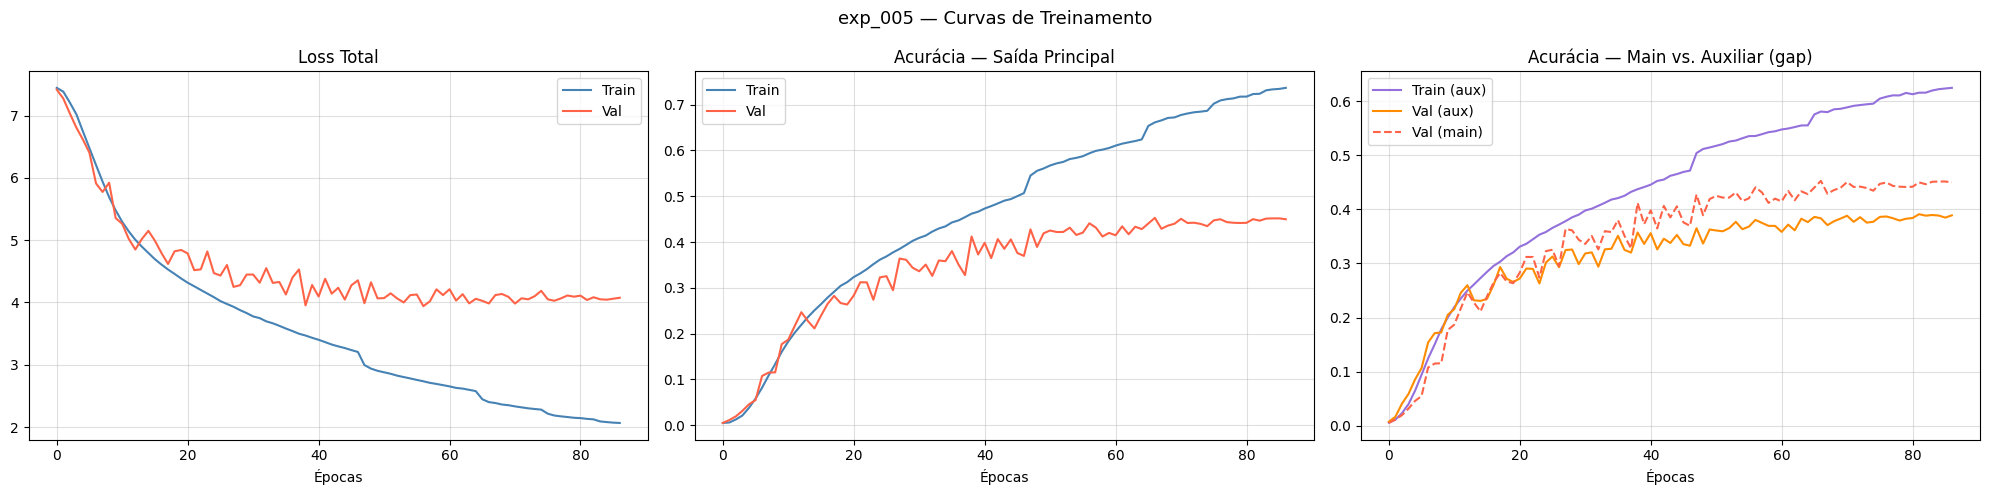

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss total
axes[0].plot(history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato')
axes[0].set_title('Loss Total')
axes[0].set_xlabel('Épocas'); axes[0].legend(); axes[0].grid(alpha=0.4)

# Acurácia saída principal
axes[1].plot(history.history['main_output_accuracy'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_main_output_accuracy'], label='Val',   color='tomato')
axes[1].set_title('Acurácia — Saída Principal')
axes[1].set_xlabel('Épocas'); axes[1].legend(); axes[1].grid(alpha=0.4)

# Acurácia saída auxiliar (acompanhar gap)
axes[2].plot(history.history['auxiliary_output_accuracy'],     label='Train (aux)', color='mediumpurple')
axes[2].plot(history.history['val_auxiliary_output_accuracy'], label='Val (aux)',   color='darkorange')
axes[2].plot(history.history['val_main_output_accuracy'],      label='Val (main)',  color='tomato', linestyle='--')
axes[2].set_title('Acurácia — Main vs. Auxiliar (gap)')
axes[2].set_xlabel('Épocas'); axes[2].legend(); axes[2].grid(alpha=0.4)

plt.suptitle('exp_005 — Curvas de Treinamento', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves_exp005.png', dpi=150)
plt.show()

In [13]:
# Carrega words.txt para nomes legíveis
id_to_name = {}
words_file = DATA_DIR / 'words.txt'
if words_file.exists():
    with open(words_file) as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                id_to_name[parts[0]] = parts[1].split(',')[0]

idx_to_name = {i: id_to_name.get(cid, cid) for i, cid in enumerate(CLASS_NAMES)}
print('Mapeamento carregado. Exemplos:')
for i in range(5):
    print(f'  [{i}] {CLASS_NAMES[i]} → {idx_to_name[i]}')

Mapeamento carregado. Exemplos:
  [0] n01443537 → goldfish
  [1] n01629819 → European fire salamander
  [2] n01641577 → bullfrog
  [3] n01644900 → tailed frog
  [4] n01698640 → American alligator


In [14]:
# Coleta predições completas sobre o val set
all_true, all_pred, all_probs = [], [], []
for imgs, (lbls, _) in val_ds_dual:
    lbl_idx = tf.argmax(lbls, axis=1).numpy()
    probs   = best_model(imgs, training=False)[0].numpy()
    all_true.extend(lbl_idx)
    all_pred.extend(np.argmax(probs, axis=1))
    all_probs.append(probs)

all_true  = np.array(all_true)
all_pred  = np.array(all_pred)
all_probs = np.concatenate(all_probs, axis=0)

# Top-5
top5_metric = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)
top5_metric.update_state(all_true, all_probs)
top5_acc = top5_metric.result().numpy()

per_class_acc = {
    c: (all_pred[all_true == c] == c).mean()
    for c in range(NUM_CLASSES) if (all_true == c).sum() > 0
}
sorted_acc = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)

print(f"{'='*50}")
print(f"  Top-1 Accuracy  : {(all_true == all_pred).mean()*100:.2f}%")
print(f"  Top-5 Accuracy  : {top5_acc*100:.2f}%")
print(f"  Média per-class : {np.mean(list(per_class_acc.values()))*100:.2f}%")
print(f"  Melhor classe   : {idx_to_name.get(sorted_acc[0][0])} ({sorted_acc[0][1]*100:.1f}%)")
print(f"  Pior classe     : {idx_to_name.get(sorted_acc[-1][0])} ({sorted_acc[-1][1]*100:.1f}%)")
print(f"{'='*50}")

  Top-1 Accuracy  : 45.27%
  Top-5 Accuracy  : 70.31%
  Média per-class : 45.27%
  Melhor classe   : monarch (88.0%)
  Pior classe     : plunger (0.0%)


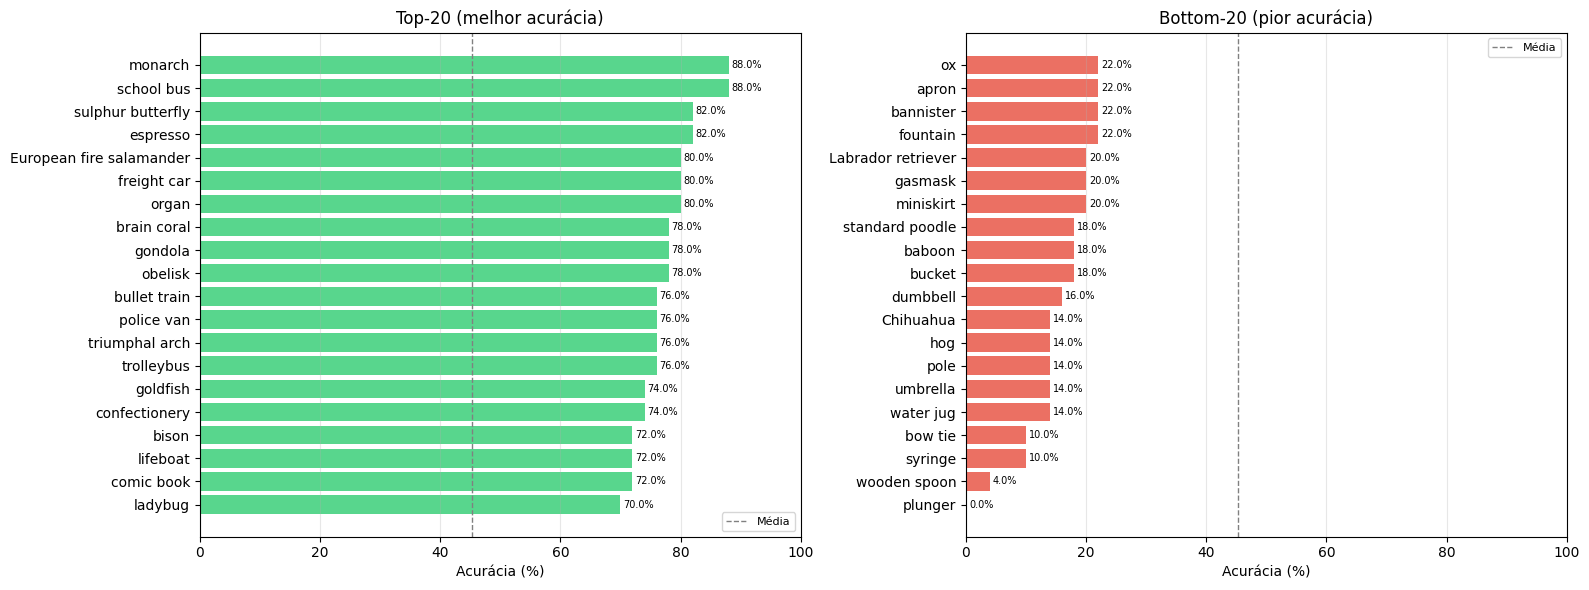

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, color in [
    (axes[0], sorted_acc[:20],  'Top-20 (melhor acurácia)', '#2ecc71'),
    (axes[1], sorted_acc[-20:], 'Bottom-20 (pior acurácia)', '#e74c3c'),
]:
    lbls = [idx_to_name.get(c, str(c)) for c, _ in data]
    vals = [v * 100 for _, v in data]
    bars = ax.barh(lbls[::-1], vals[::-1], color=color, alpha=0.8)
    ax.axvline(np.mean(list(per_class_acc.values())) * 100,
               color='gray', linestyle='--', lw=1, label='Média')
    ax.set_xlabel('Acurácia (%)'); ax.set_title(title)
    ax.set_xlim(0, 100); ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, vals[::-1]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('per_class_exp005.png', dpi=150, bbox_inches='tight')
plt.show()

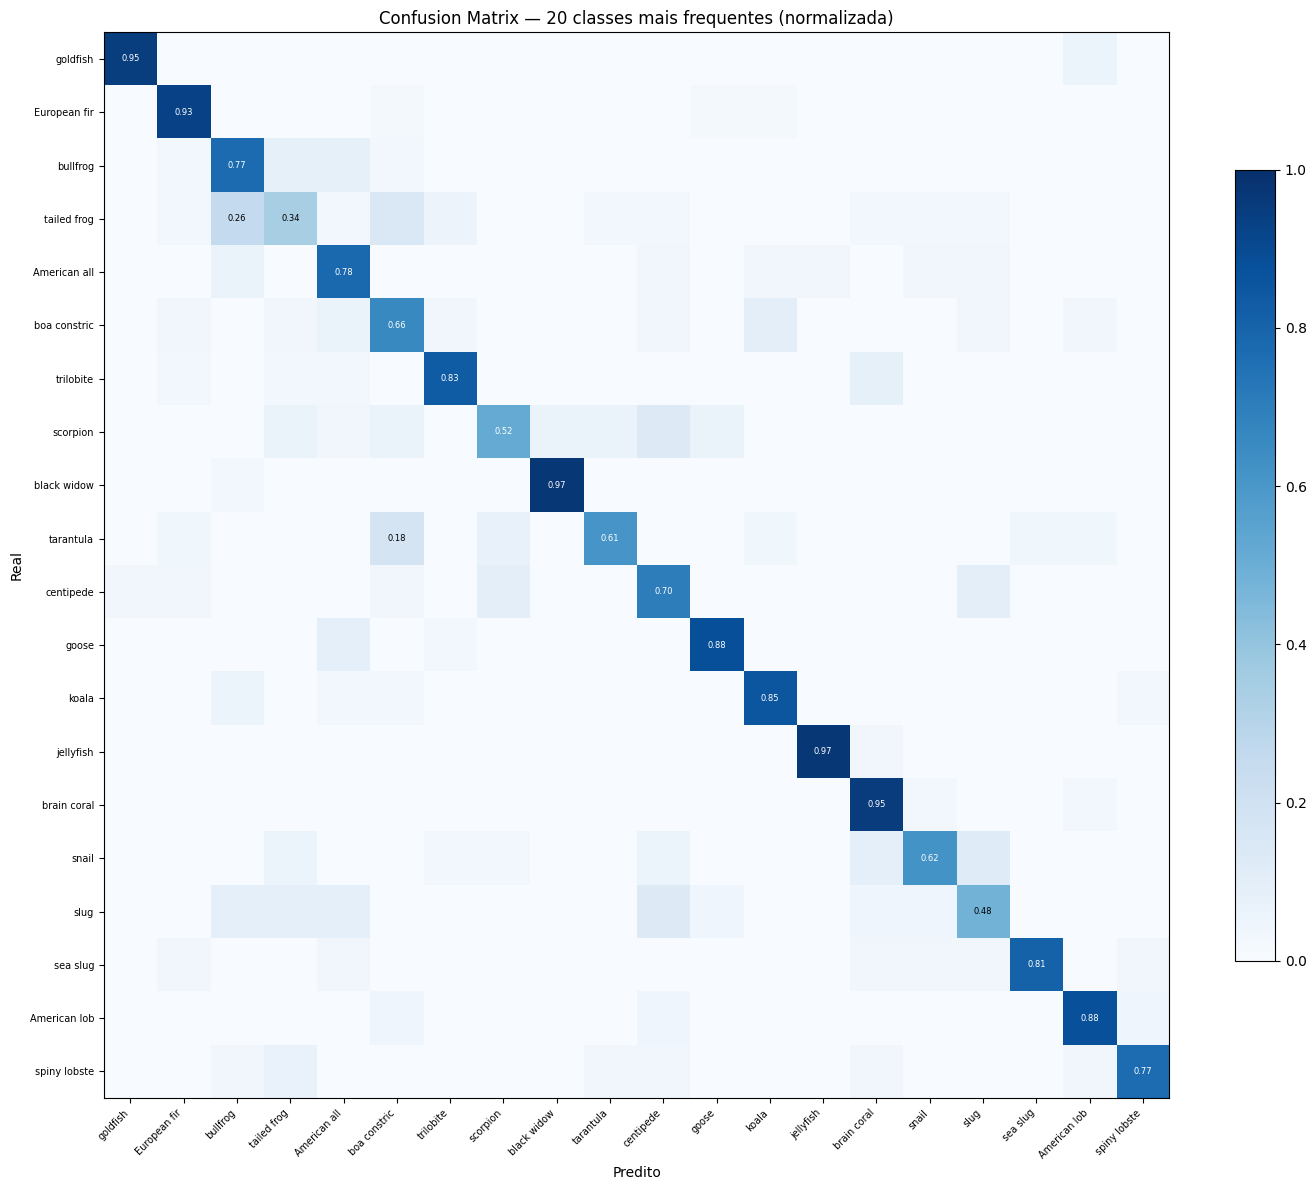

In [16]:
top20_idx = [c for c, _ in sorted(
    ((c, (all_true == c).sum()) for c in range(NUM_CLASSES)), key=lambda x: -x[1]
)[:20]]

mask = np.isin(all_true, top20_idx)
cm   = confusion_matrix(all_true[mask], all_pred[mask], labels=top20_idx)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03)
tick_lbl = [idx_to_name.get(c, str(c))[:12] for c in top20_idx]
ax.set_xticks(range(20)); ax.set_xticklabels(tick_lbl, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(20)); ax.set_yticklabels(tick_lbl, fontsize=7)
ax.set_title('Confusion Matrix — 20 classes mais frequentes (normalizada)')
ax.set_ylabel('Real'); ax.set_xlabel('Predito')
for i, j in itertools.product(range(20), range(20)):
    if cm_n[i, j] > 0.15:
        ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_n[i,j] > 0.5 else 'black', fontsize=6)
plt.tight_layout()
plt.savefig('confusion_matrix_exp005.png', dpi=150, bbox_inches='tight')
plt.show()

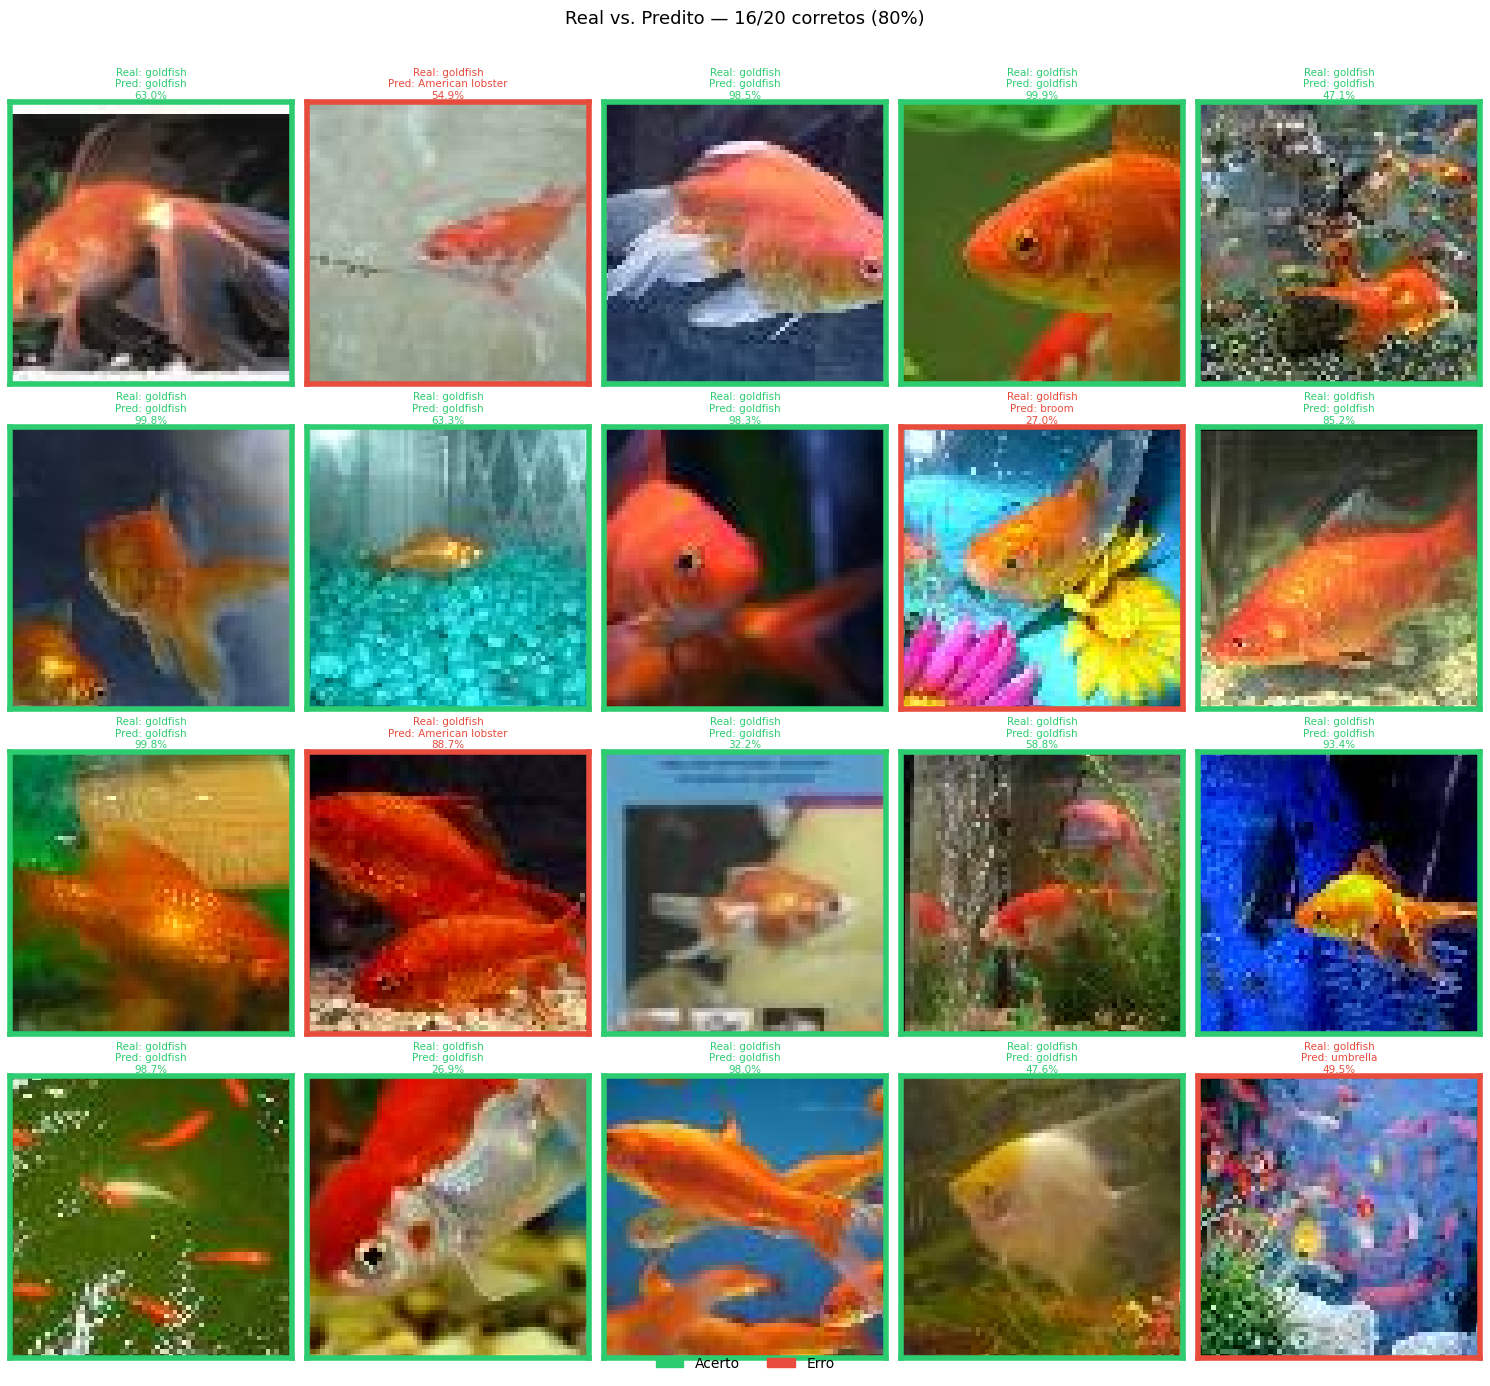

In [17]:
N, COLS = 20, 5
ROWS = math.ceil(N / COLS)

sample_imgs, (sample_lbls, _) = next(iter(val_ds_dual))
sample_imgs = sample_imgs[:N]
true_idx    = tf.argmax(sample_lbls[:N], axis=1).numpy()
probs_main  = best_model(sample_imgs, training=False)[0].numpy()
pred_idx    = np.argmax(probs_main, axis=1)
confs       = np.max(probs_main, axis=1)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS*3, ROWS*3.4))
for i, ax in enumerate(axes.flat[:N]):
    correct = true_idx[i] == pred_idx[i]
    cor = '#2ecc71' if correct else '#e74c3c'
    ax.imshow(sample_imgs[i].numpy())
    for s in ax.spines.values():
        s.set_edgecolor(cor); s.set_linewidth(4)
    ax.set_title(
        f"Real: {idx_to_name.get(true_idx[i], '')}\n"
        f"Pred: {idx_to_name.get(pred_idx[i], '')}\n{confs[i]*100:.1f}%",
        fontsize=7.5, color=cor, pad=3
    )
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for ax in axes.flat[N:]:
    ax.axis('off')

n_ok = (true_idx == pred_idx).sum()
fig.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Acerto'),
    mpatches.Patch(color='#e74c3c', label='Erro')
], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0), frameon=False)
fig.suptitle(f'Real vs. Predito — {n_ok}/{N} corretos ({n_ok/N*100:.0f}%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('real_vs_predito_exp005.png', dpi=150, bbox_inches='tight')
plt.show()

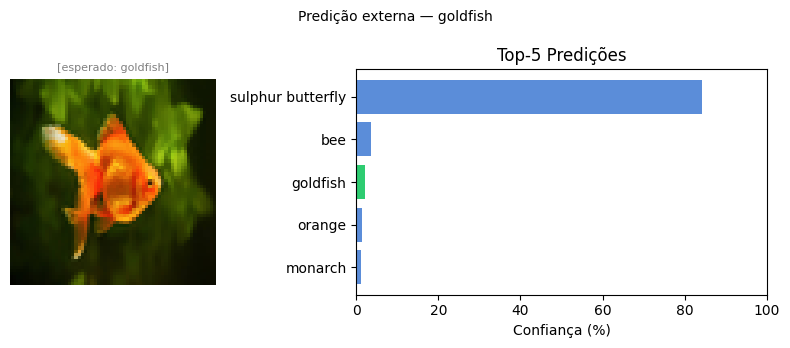

  Top-1: sulphur butterfly (84.1%) | esperado: goldfish


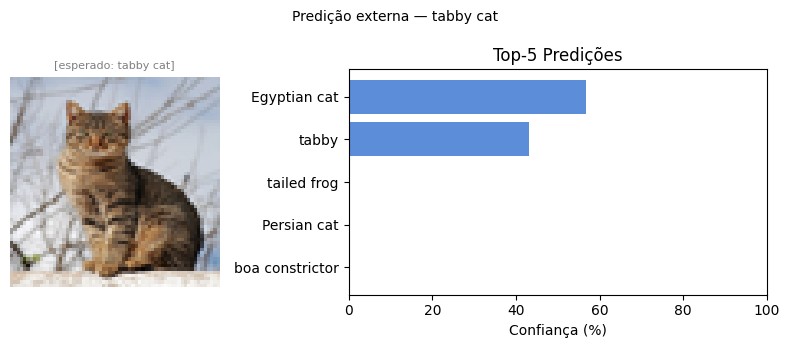

  Top-1: Egyptian cat (56.8%) | esperado: tabby cat


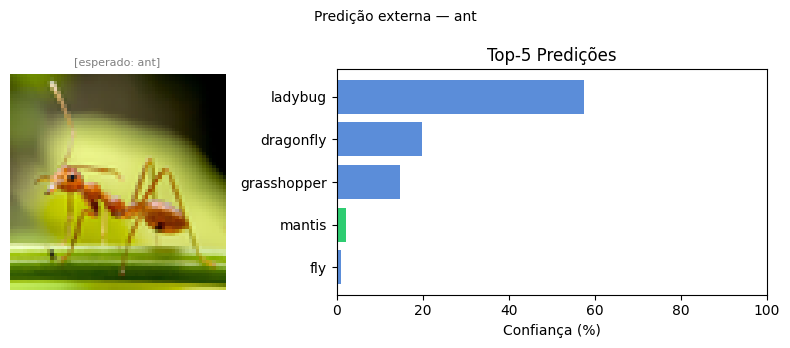

  Top-1: ladybug (57.5%) | esperado: ant


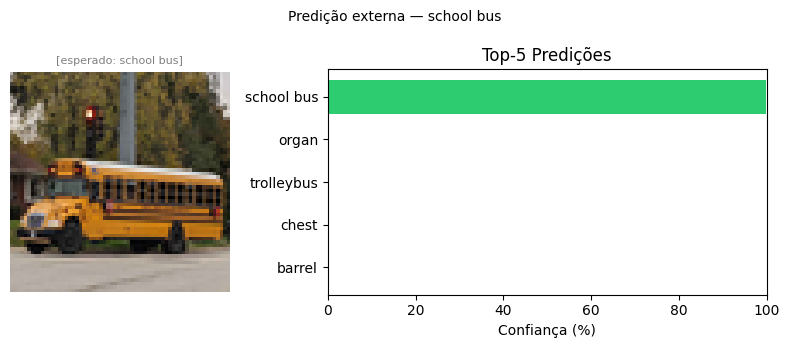

  Top-1: school bus (99.8%) | esperado: school bus


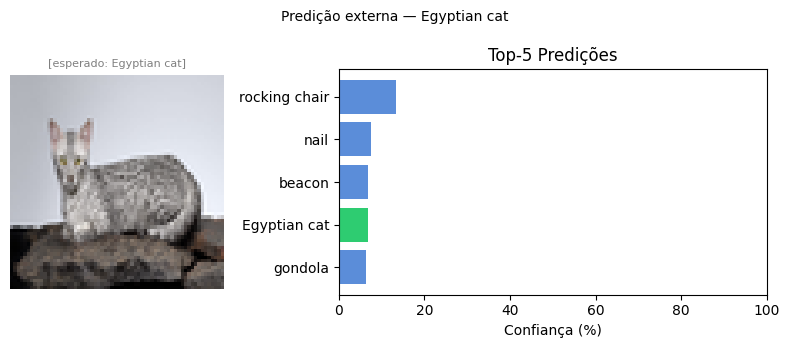

  Top-1: rocking chair (13.4%) | esperado: Egyptian cat


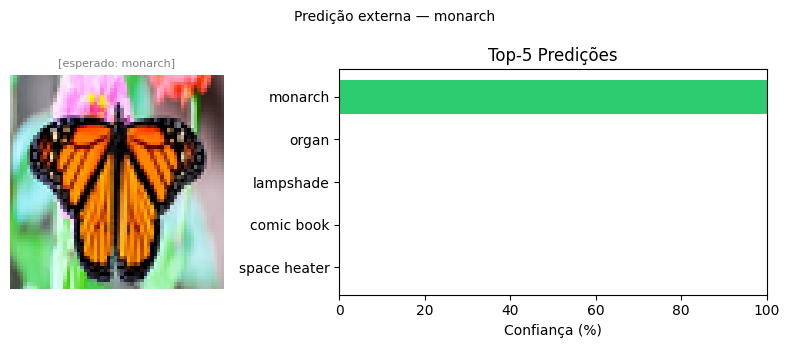

  Top-1: monarch (100.0%) | esperado: monarch


In [18]:
# URLs de imagens públicas cobrindo classes presentes no Tiny ImageNet
TEST_URLS = [
    # goldfish (n01443537)
    ('goldfish',      'https://cafishvet.com/wp-content/uploads/2020/10/gold-fish-1.jpg'),
    # tabby cat (n02123045)
    ('tabby cat',     'https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/960px-Cat_November_2010-1a.jpg'),
    # ant (n02165456)
    ('ant',           'https://cdn.britannica.com/42/223142-050-7033F421/Red-ant-on-a-green-branch.jpg'),
    # school bus (n04376876)
    ('school bus',    'https://ipmnewsroom.org/wp-content/uploads/2023/11/SchoolBus_WEB.jpg'),
    # Egyptian cat (n02124075)
    ('Egyptian cat',  'https://www.purina.co.uk/sites/default/files/2022-02/GettyImages-1250476831.jpg'),
    # monarch butterfly (n02281406)
    ('monarch',       'https://wildlife.org/wp-content/uploads/2026/01/monarch.png'),
]

def predict_url(label, url, top_k=5):
    """Baixa imagem, redimensiona para IMG_SIZE e exibe top-k predições."""
    try:
        r   = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
        img = Image.open(BytesIO(r.content)).convert('RGB')
        img_r = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        arr   = np.array(img_r, dtype=np.float32)[None] / 255.0

        probs     = best_model(arr, training=False)[0][0].numpy()
        top_idx   = np.argsort(probs)[::-1][:top_k]

        fig, axes = plt.subplots(1, 2, figsize=(8, 3.5),
                                 gridspec_kw={'width_ratios': [1, 2]})
        axes[0].imshow(img_r); axes[0].axis('off')
        axes[0].set_title(f'[esperado: {label}]', fontsize=8, color='gray')

        names = [idx_to_name.get(i, str(i)) for i in top_idx]
        vals  = [probs[i]*100 for i in top_idx]
        colors = ['#2ecc71' if label.lower() in n.lower() else '#5b8dd9' for n in names]
        axes[1].barh(names[::-1], vals[::-1], color=colors[::-1])
        axes[1].set_xlabel('Confiança (%)')
        axes[1].set_title('Top-5 Predições')
        axes[1].set_xlim(0, 100)

        plt.suptitle(f'Predição externa — {label}', fontsize=10)
        plt.tight_layout()
        plt.show()

        print(f'  Top-1: {names[0]} ({vals[0]:.1f}%) | esperado: {label}')
    except Exception as e:
        print(f'  Erro ({label}): {e}')

for lbl, url in TEST_URLS:
    predict_url(lbl, url)

In [19]:
EXPERIMENTO['resultado_top1'] = round(float(results[3]) * 100, 2)
EXPERIMENTO['resultado_top5'] = round(float(top5_acc) * 100, 2)
EXPERIMENTO['epocas']         = len(history.history['loss'])

log_path   = 'experimentos_log.csv'
fieldnames = ['id', 'hipotese', 'mudancas', 'resultado_top1', 'resultado_top5', 'epocas', 'timestamp']
row = {
    **EXPERIMENTO,
    'mudancas':  ' | '.join(EXPERIMENTO['mudancas']),
    'timestamp': datetime.datetime.now().isoformat(),
}
file_exists = os.path.isfile(log_path)
with open(log_path, 'a', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()
    writer.writerow(row)

print(f'✓ {EXPERIMENTO["id"]} salvo em {log_path}')
print(f'  Top-1: {EXPERIMENTO["resultado_top1"]}% | Top-5: {EXPERIMENTO["resultado_top5"]}% | Épocas: {EXPERIMENTO["epocas"]}')

✓ exp_005 salvo em experimentos_log.csv
  Top-1: 38.35% | Top-5: 70.31% | Épocas: 87


## Resumo — exp_005
| Métrica | Baseline | EXP01 | EXP02 | EXP03 ❌ | EXP04 | **EXP05** |
|---|---|---|---|---|---|---|
| Top-1 val (principal) | 39.88% | 40.08% | 39.29% | 0.50% | 41.88% | *(preencher)* |
| Top-1 val (auxiliar) | — | 44.76% | 46.58% | 2.50% | 47.52% | *(preencher)* |
| Top-5 val | — | 71.05% | 71.79% | 2.50% | 71.91% | *(preencher)* |
| Épocas | — | 66 | 94 | 16 | 88 | *(preencher)* |

**Mudanças acumuladas vs baseline:**
- `inception_5a/5b`: canais reduzidos ~30% (exp_001)
- `main_dropout`: 0.4 → 0.55 (exp_002)
- `label_smoothing`: 0.05 **só na main_output** (exp_004)
- `loss_weight` auxiliar: 0.3 → 0.4 (exp_004)
- `scheduler`: ReduceLROnPlateau patience=8 (exp_004)
- `early_stopping`: patience=20 (exp_004)
- `LR warmup`: 5 épocas de 0.001 → 0.01 (exp_004)
- `augmentation`: nível exp_002 (exp_004)
- **`stem_c2`: stride=2, `he_normal` — `stem_pool` removido (exp_005)** ← mudança isolada

**Diagnóstico do gap main/aux:**
> O gap de ~7pp entre saída auxiliar e principal observado no exp_002 sugere dissipação
> de gradiente nos blocos 4e → pool_4 → 5a → 5b → GAP → main_output.
> A Stem mais eficiente (exp_005) melhora o fluxo inicial, mas se o gap persistir
> após exp_005, o próximo passo deve focar nos blocos finais (ex: Dropout leve após 4e).